# **CONTOH PERHITUNGAN CONFUSION MATRIX**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
# DATA DUMMY (10 sampel)

y_true = ['Rendah', 'Rendah', 'Sedang', 'Tinggi', 'Rendah',
          'Sedang', 'Tinggi', 'Rendah', 'Sedang', 'Tinggi']

y_pred = ['Rendah', 'Rendah', 'Sedang', 'Tinggi', 'Rendah',
          'Sedang', 'Tinggi', 'Sedang', 'Sedang', 'Sedang']

kelas = ['Rendah', 'Sedang', 'Tinggi']

In [ ]:
# HITUNG CONFUSION MATRIX

cm = confusion_matrix(y_true, y_pred, labels=kelas)

print(f"{'':15} {'Pred:Rendah':>12} {'Pred:Sedang':>12} {'Pred:Tinggi':>12}")
print("-" * 50)
for i, baris in enumerate(kelas):
    print(f"Asli:{baris:10} {cm[i][0]:>12} {cm[i][1]:>12} {cm[i][2]:>12}")

                 Pred:Rendah  Pred:Sedang  Pred:Tinggi
--------------------------------------------------
Asli:Rendah                3            1            0
Asli:Sedang                0            3            0
Asli:Tinggi                0            1            2


In [ ]:
# HITUNG TP, FP, FN, TN + METRIK PER KELAS
n = len(y_true)
for i, nama in enumerate(kelas):
    TP = cm[i][i]
    FP = cm[:, i].sum() - TP   # kolom i dikurangi diagonal
    FN = cm[i, :].sum() - TP   # baris i dikurangi diagonal
    TN = n - TP - FP - FN

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0)

    print(f"\nKelas: {nama}")
    print(f"  TP={TP}  FP={FP}  FN={FN}  TN={TN}")
    print(f"  Precision = {TP}/({TP}+{FP}) = {precision:.4f}")
    print(f"  Recall    = {TP}/({TP}+{FN}) = {recall:.4f}")
    print(f"  F1-Score  = 2x({precision:.4f}x{recall:.4f})/({precision:.4f}+{recall:.4f}) = {f1:.4f}")

accuracy = cm.diagonal().sum() / n
print(f"\nAccuracy = {cm.diagonal().sum()}/{n} = {accuracy:.4f} ({accuracy*100:.1f}%)")



Kelas: Rendah
  TP=3  FP=0  FN=1  TN=6
  Precision = 3/(3+0) = 1.0000
  Recall    = 3/(3+1) = 0.7500
  F1-Score  = 2x(1.0000x0.7500)/(1.0000+0.7500) = 0.8571

Kelas: Sedang
  TP=3  FP=2  FN=0  TN=5
  Precision = 3/(3+2) = 0.6000
  Recall    = 3/(3+0) = 1.0000
  F1-Score  = 2x(0.6000x1.0000)/(0.6000+1.0000) = 0.7500

Kelas: Tinggi
  TP=2  FP=0  FN=1  TN=7
  Precision = 2/(2+0) = 1.0000
  Recall    = 2/(2+1) = 0.6667
  F1-Score  = 2x(1.0000x0.6667)/(1.0000+0.6667) = 0.8000

Accuracy = 8/10 = 0.8000 (80.0%)


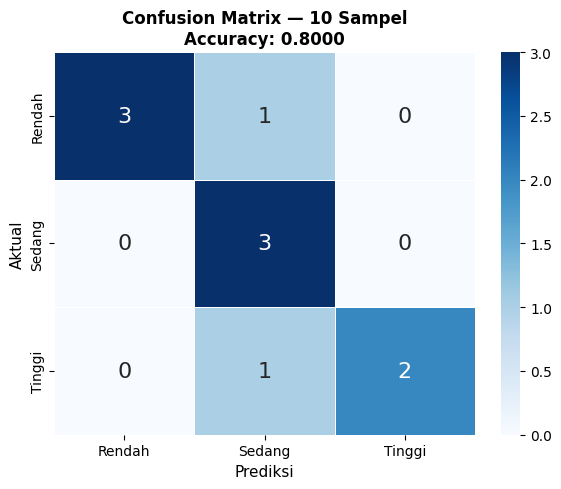

In [ ]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=kelas,
            yticklabels=kelas,
            linewidths=0.5,
            linecolor='white',
            ax=ax,
            annot_kws={'size': 16})

ax.set_xlabel('Prediksi', fontsize=11)
ax.set_ylabel('Aktual', fontsize=11)
ax.set_title(f"Confusion Matrix — 10 Sampel\n"
             f"Accuracy: {accuracy:.4f}",
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix_hasil.png', dpi=150, bbox_inches='tight')
plt.show()